# Joint learning of morphology and syntax with cross-level contextual information flow
Çapraz düzey bağlamsal bilgi akışı ile morfoloji ve sözdiziminin birlikte öğrenilmesi

29 April 2020

In [2]:
vocab = (
    ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<MASK>', ' '] +
    
    list('abcçdefgğhıijklmnoöprsştuüvyz') +
    list('ABCÇDEFGĞHIİJKLMNOÖPRSŞTUÜVYZ') +
    list('0123456789') +
    
    ['.',',',';',':','?','!','"',"'",'(',')','[',']','{','}','-','–','—','…','/','\\','|'] +
    
    ['\n']
)

['<PAD>',   # padding (sequence equalization)
 '<UNK>',   # bilinmeyen karakter
 '<BOS>',   # beginning of sentence
 '<EOS>',   # end of sentence
 '<MASK>',  # masking (BERT tarzı)
 ' ']       # boşluk (space)

['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<MASK>', ' ']

In [19]:

# char → index
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
vocab_size = len(vocab)


def one_hot_encode_vertical(text):
    """
    return: (vocab_size, len(text)) one-hot matrix (dikey)
    """

    result = np.zeros((vocab_size, len(text)), dtype=np.int32)

    for i, ch in enumerate(text):
        if ch in char_to_idx:
            idx = char_to_idx[ch]
        else:
            idx = char_to_idx['<UNK>']

        result[idx, i] = 1  # 🔥 yön değişti

    return result
def one_hot_encode(text):
    """
    return: (len(text), vocab_size) one-hot matrix
    """

    result = np.zeros((len(text), vocab_size), dtype=np.int32)

    for i, ch in enumerate(text):
        if ch in char_to_idx:
            idx = char_to_idx[ch]
        else:
            idx = char_to_idx['<UNK>']

        result[i, idx] = 1  # 🔥 eski yön

    return result


In [23]:
text = "merhaba dünya!"
print(len(text))
encoded = one_hot_encode(text)

# np.set_printoptions(threshold=np.inf)
print(encoded.shape)  # (len(text), vocab_size)
print(encoded)


14
(14, 96)
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

(14, 96)
(14, 96)


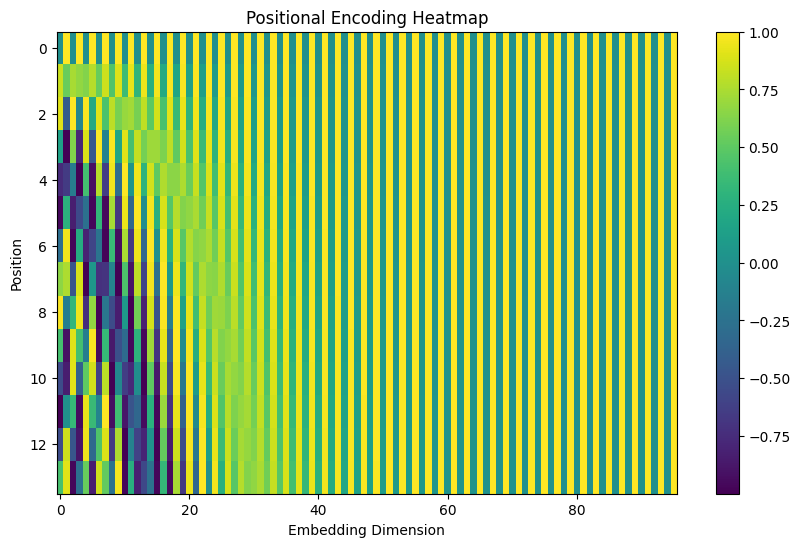

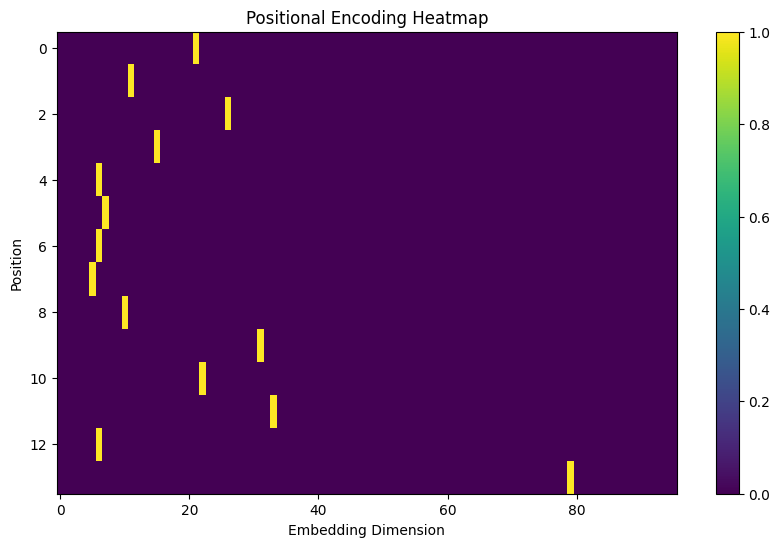

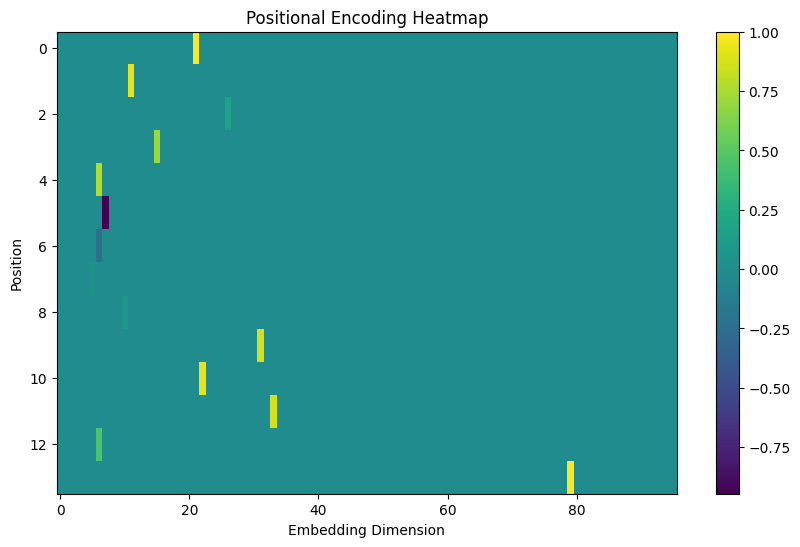

In [26]:
import numpy as np
import matplotlib.pyplot as plt


def get_angle(pos, i, d_model):
    """
    Pozisyon ve boyut indeksine göre açı değerini hesaplar
    """
    return pos / (10000 ** ((2 * (i // 2)) / d_model))


def positional_encoding_matrix(seq_len, d_model):
    """
    Tüm positional encoding matrisini oluşturur
    """
    PE = np.zeros((seq_len, d_model))


    for pos in range(seq_len):
        for i in range(d_model):
            angle = get_angle(pos, i, d_model)
            if i % 2 == 0:
                PE[pos, i] = np.sin(angle)
            else:
                PE[pos, i] = np.cos(angle)

    return PE


def plot_positional_encoding(pe):
    """
    Positional encoding matrisini görselleştirir
    """
    plt.figure(figsize=(10, 6))
    plt.imshow(pe, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title("Positional Encoding Heatmap")
    plt.xlabel("Embedding Dimension")
    plt.ylabel("Position")
    plt.show()


def main():
    seq_len = len(text)
    d_model = vocab_size

    # # seq_arr = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,3,4]
    # # seq_arr = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
    # seq_arr = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

    # sentence_embed = np.ones((len(seq_arr), d_model))

    # sentence_embed[10,:] = 0.3



    pe = positional_encoding_matrix(len(text), d_model)
    # np.set_printoptions(threshold=np.inf)
    # print(pe)

    print(pe.shape )
    print(encoded.shape)
    plot_positional_encoding(pe)

    pe = pe * encoded

    plot_positional_encoding(encoded)
    plot_positional_encoding(pe)


if __name__ == "__main__":
    main()